<a href="https://colab.research.google.com/github/HoaiPhuong-Nguyen/AIHC5020/blob/main/final_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Problem 1
import pandas as pd

data = [
    {
        "name": "Integer",
        "python_symbol": "int",
        "example": str(38),
        "falsy_value": "0",
        "usage": "Represents whole numbers"
    },
    {
        "name": "Float",
        "python_symbol": "float",
        "example": str(1.024),
        "falsy_value": "0.0",
        "usage": "Represents decimal numbers"
    },
    {
        "name": "Complex",
        "python_symbol": "complex",
        "example": str(1 + 2j),
        "falsy_value": "0j",
        "usage": "Represents complex numbers with real and imaginary parts"
    },
    {
        "name": "Boolean",
        "python_symbol": "bool",
        "example": str(True),
        "falsy_value": "False",
        "usage": "Represents truth values (True/False)"
    },
    {
        "name": "String",
        "python_symbol": "str",
        "example": str("hello world"),
        "falsy_value": "''",
        "usage": "Represents text data"
    },
    {
        "name": "NoneType",
        "python_symbol": "NoneType",
        "example": str(None),
        "falsy_value": "None",
        "usage": "Represents the absence of a value"
    },
    {
        "name": "List",
        "python_symbol": "list",
        "example": str([1, 2, 3]),
        "falsy_value": "[]",
        "usage": "Ordered, mutable collection of items"
    },
    {
        "name": "Tuple",
        "python_symbol": "tuple",
        "example": str((4, 5, 6)),
        "falsy_value": "()",
        "usage": "Ordered, immutable collection of items"
    },
    {
        "name": "Dictionary",
        "python_symbol": "dict",
        "example": str({"a": 1, "b": 2}),
        "falsy_value": "{}",
        "usage": "Collection of key-value pairs"
    },
]

df = pd.DataFrame(data)
print(df)


         name python_symbol           example falsy_value  \
0     Integer           int                38           0   
1       Float         float             1.024         0.0   
2     Complex       complex            (1+2j)          0j   
3     Boolean          bool              True       False   
4      String           str       hello world          ''   
5    NoneType      NoneType              None        None   
6        List          list         [1, 2, 3]          []   
7       Tuple         tuple         (4, 5, 6)          ()   
8  Dictionary          dict  {'a': 1, 'b': 2}          {}   

                                               usage  
0                           Represents whole numbers  
1                         Represents decimal numbers  
2  Represents complex numbers with real and imagi...  
3               Represents truth values (True/False)  
4                               Represents text data  
5                  Represents the absence of a value  
6   

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import auth

auth.authenticate_user()

In [7]:
# Problem 2
from google.cloud import storage
import pandas as pd
import json
from datetime import datetime
from io import StringIO

def load_chat_log(chat_id: int, bucket_name="cloud-samples-data", prefix="ccai/sample-chat-logs"):
    """
    Load a chat log from Google Cloud Storage and return a Pandas DataFrame.

    Args:
        chat_id (int): The chat log integer ID.
        bucket_name (str): The GCS bucket name. Default is 'cloud-samples-data'.
        prefix (str): The prefix path inside the bucket. Default is 'ccai/sample-chat-logs'.

    Returns:
        pd.DataFrame or None
    """
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob_name = f"{prefix}/{chat_id}.json"
    blob = bucket.blob(blob_name)

    if not blob.exists():
        print(f"No chat log found for ID {chat_id}.")
        return None

    data = blob.download_as_text()
    chat_json = json.loads(data)

    df = pd.DataFrame(chat_json["messages"])
    df["timestamp"] = df["timestamp_usec"].apply(
        lambda us: datetime.utcfromtimestamp(us / 1e6).strftime("%Y-%m-%d %H:%M:%S")
    )

    if {"timestamp", "sender", "text"} <= set(df.columns):
        df = df[["timestamp", "sender", "text"]]
    else:
        df = df

    return df


chat_df = load_chat_log(101)

if chat_df is not None:
    print(chat_df.head())


No chat log found for ID 101.


In [11]:
# Problem 3

import os
import pydicom
import pandas as pd
from collections import defaultdict

def create_dicom_manifest(dicom_root: str) -> pd.DataFrame:
    """
    Scan a folder of DICOM files and create a manifest DataFrame summarizing series.

    Args:
        dicom_root (str): Path to the root directory containing DICOM files.

    Returns:
        pd.DataFrame: Manifest with one row per series.
    """
    series_dict = defaultdict(lambda: {
        "study_uid": None,
        "patient_id": None,
        "study_date": None,
        "modality": None,
        "num_images": 0,
        "series_dir": None
    })

    for root, _, files in os.walk(dicom_root):
        for f in files:
            file_path = os.path.join(root, f)
            try:
                dcm = pydicom.dcmread(file_path, stop_before_pixels=True)

                series_uid = getattr(dcm, "SeriesInstanceUID", None)
                if not series_uid:
                    continue  # skip if no series

                entry = series_dict[series_uid]

                entry["study_uid"] = getattr(dcm, "StudyInstanceUID", None)
                entry["patient_id"] = getattr(dcm, "PatientID", None)
                entry["study_date"] = getattr(dcm, "StudyDate", None)
                entry["modality"] = getattr(dcm, "Modality", None)
                entry["num_images"] += 1
                entry["series_dir"] = root
            except Exception as e:
                continue

    manifest = pd.DataFrame([
        {
            "series_uid": series_uid,
            "study_uid": values["study_uid"],
            "patient_id": values["patient_id"],
            "study_date": values["study_date"],
            "modality": values["modality"],
            "num_images": values["num_images"],
            "series_dir": values["series_dir"]
        }
        for series_uid, values in series_dict.items()
    ])

    return manifest



In [12]:
# Test Problem 3

dicom_root = "/content/drive/MyDrive/AIHC5020/dicom/chest_xray"
manifest_df = create_dicom_manifest(dicom_root)

print(manifest_df.head())

                                          series_uid  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.140111454550...   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.541650212189...   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.334422875695...   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.140614242738...   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.239368516910...   

                                           study_uid      patient_id  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.213083367261...  LIDC-IDRI-0015   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.675114969651...  LIDC-IDRI-0023   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.302822025885...  LIDC-IDRI-0040   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.269469709045...  LIDC-IDRI-0014   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.333103030188...  LIDC-IDRI-0012   

  study_date modality  num_images  \
0   20000101       DX           1   
1   20000101       DX           2   
2   20000101       DX           2   
3   20000101       DX           2   
4   20000101       DX           2   

       

In [16]:
# Problem 4
import os
import pydicom
import matplotlib.pyplot as plt
import math

def visualize_patient_series(patient_id: str, manifest_df, dicom_root: str):
    """
    Visualize all DICOM instances for a given patient ID.

    Args:
        patient_id (str): Patient ID to visualize.
        manifest_df (pd.DataFrame): Manifest DataFrame (from create_dicom_manifest).
        dicom_root (str): Root directory of DICOM files.

    Returns:
        None
    """
    patient_series = manifest_df[manifest_df["patient_id"] == patient_id]
    if patient_series.empty:
        print(f"No series found for patient {patient_id}.")
        return None

    file_paths = []
    for _, row in patient_series.iterrows():
        series_dir = row["series_dir"]
        for f in os.listdir(series_dir):
            file_paths.append(os.path.join(series_dir, f))

    if not file_paths:
        print(f"No DICOM files found for patient {patient_id}.")
        return None

    images = []
    for path in sorted(file_paths):
        try:
            dcm = pydicom.dcmread(path)
            if hasattr(dcm, "pixel_array"):
                images.append(dcm.pixel_array)
        except Exception as e:
            continue

    if not images:
        print(f"No image data available for patient {patient_id}.")
        return None

    n_images = len(images)
    cols = min(4, n_images)
    rows = math.ceil(n_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))

    # Flatten the axes array for easy iteration
    if isinstance(axes, plt.Axes):
        axes = np.array([axes]) # Handle single plot case
    axes = axes.flatten()


    idx = 0
    for ax in axes:
            if idx < n_images:
                ax.imshow(images[idx], cmap="gray")
                ax.set_title(f"Image {idx+1}")
                ax.axis("off")
                idx += 1
            else:
                ax.axis("off")

    plt.suptitle(f"Patient {patient_id}: {n_images} instance(s)", fontsize=16)
    plt.tight_layout()
    plt.show()

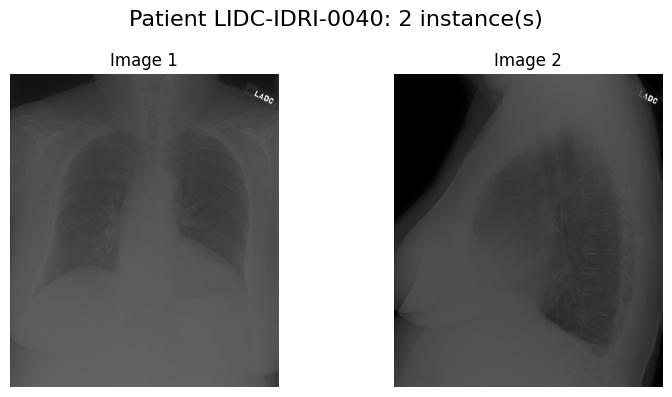

In [17]:
# Test problem 4

dicom_root = "/content/drive/MyDrive/AIHC5020/dicom/chest_xray"
visualize_patient_series("LIDC-IDRI-0040", manifest_df, dicom_root)